In [339]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline


In [276]:
df = pd.read_csv(r"C:\Users\TALIGENT\Downloads\CreditScoring-master\CreditScoring-master\CreditScoring.csv")


In [277]:
df.columns = df.columns.str.lower()
df.home.value_counts()

home
2    2107
1     973
5     783
6     319
3     247
4      20
0       6
Name: count, dtype: int64

In [278]:
#Mapeamos y cambiamos los valores de numero a string correspondiente
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [279]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [280]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [281]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value= np.nan)

for c in df.columns:
    df[c] = df[c].fillna(0)


In [282]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,130.0,5346.0,342.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,87.0,11525.0,1244.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,119.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,164.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [283]:
# Elimino los unk y reseteo indices
df = df[df.status != 'unk'].reset_index(drop=True)

In [284]:
df.shape

(4454, 14)

In [285]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)
df_full_train.reset_index(drop=True)

y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

del df_train['status']
del df_val['status']
del df_test['status']



In [286]:
## Modelo
train_dicts= df_train.to_dict(orient= 'records')
dv = DictVectorizer(sparse= False)
X_train = dv.fit_transform(train_dicts)


In [287]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [288]:
val_dicts= df_val.to_dict(orient= 'records')
X_val = dv.transform(val_dicts)

y_pred = dt.predict_proba(X_val)[:,1] # tomamos la segunda columna (cliente pert clase positiva)


In [289]:
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_pred, y_val)

0.6720945249618431

In [290]:
y_pred = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_pred, y_train)

# Si nos da uno es Overfitting (Modelo aprende los datos pero no entrena) 
# Pasa en modelos con mucha profundidad

1.0

In [291]:
# Limitamos la profundidad
#Datos entrenamiento
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

y_pred = dt.predict_proba(X_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)


train: 0.7761016984958594
val: 0.7389079944782155


In [292]:
# Para ver el arbol como queda
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))


|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0



In [293]:
# Tunning Parametres
for d in [1,2,3,4,5,6,10,15,20,None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:,1] 
    auc = roc_auc_score(y_val,y_pred)
    print(d,auc)   

1 0.6058644740984719
2 0.6685264343319367
3 0.7389079944782155
4 0.7612827250490422
5 0.7664957254607541
6 0.7521039693880023
10 0.6966136688382456
15 0.6610883727688843
20 0.6586423191494515
None 0.6589511031459641


In [294]:
scores = []

for d in [4,5,6]:
    for s in [1,2,5,10,15,20,100,500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:,1] 
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,s,auc))
        #print(d,s,auc)   


columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores = df_scores.sort_values(by='auc', ascending=False)
df_scores.head()


,max_depth,min_samples_leaf,auc
20,6,15,0.785319
19,6,10,0.778299
22,6,100,0.776434
21,6,20,0.773634
13,5,20,0.773537


In [295]:
df_scores_pivot = df_scores.pivot(columns='max_depth', index='min_samples_leaf', values='auc')
df_scores_pivot.round(3)

max_depth,4,5,6
min_samples_leaf,,,
1,0.761,0.766,0.749
2,0.761,0.766,0.767
5,0.761,0.768,0.762
10,0.761,0.762,0.778
15,0.764,0.772,0.785
20,0.761,0.774,0.774
100,0.756,0.763,0.776
500,0.680,0.680,0.680


<Axes: xlabel='max_depth', ylabel='min_samples_leaf'>

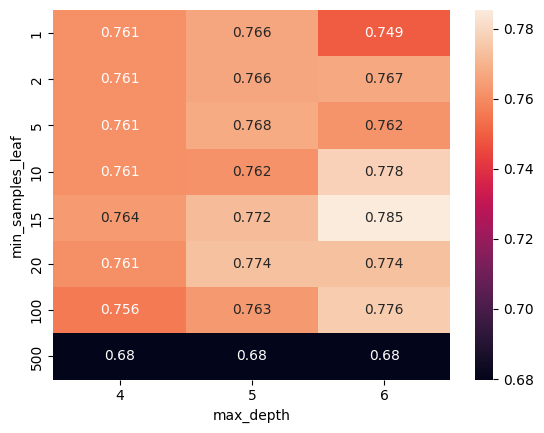

In [296]:
sns.heatmap(df_scores_pivot,annot=True,fmt=".3g")

In [297]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [298]:
# Ensemble y Ramdon Forest
from sklearn.ensemble import RandomForestClassifier

scores = []
for d in [5,10,15]:
    for r in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=r,max_depth=d, random_state=1)
        rf.fit(X_train,y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,r,auc))
scores

[(5, 10, 0.7876988932212832),
 (5, 20, 0.7977313458138577),
 (5, 30, 0.8003045457847957),
 (5, 40, 0.7997081688503548),
 (5, 50, 0.7998776973190285),
 (5, 60, 0.8011673245985809),
 (5, 70, 0.8022510958804582),
 (5, 80, 0.803244048339832),
 (5, 90, 0.8036164055120971),
 (5, 100, 0.8044519386791311),
 (5, 110, 0.8066255358310528),
 (5, 120, 0.8064499527742124),
 (5, 130, 0.8080544186384443),
 (5, 140, 0.807019084061902),
 (5, 150, 0.8072188854714104),
 (5, 160, 0.8071341212370734),
 (5, 170, 0.8069645927683999),
 (5, 180, 0.8072612675885785),
 (5, 190, 0.8072309946477441),
 (5, 200, 0.8073520864110824),
 (10, 10, 0.7913649463563488),
 (10, 20, 0.8084964035746288),
 (10, 30, 0.8115842435397544),
 (10, 40, 0.8178386331161753),
 (10, 50, 0.8170575912426437),
 (10, 60, 0.8186560025187086),
 (10, 70, 0.8202301954421061),
 (10, 80, 0.8204118330871135),
 (10, 90, 0.8198427017994235),
 (10, 100, 0.8211686566079774),
 (10, 110, 0.8226459761207041),
 (10, 120, 0.8232272165847279),
 (10, 130, 0.824

In [299]:
df_scores= pd.DataFrame(scores, columns=['max_depth','n_estimators','auc'])
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878


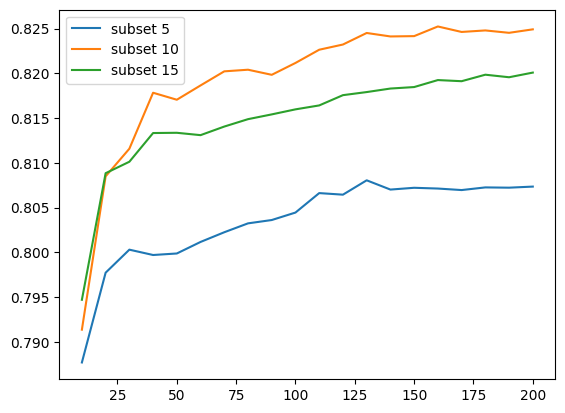

In [300]:
for d in [5,10,15]:
    df_subset = df_scores[df_scores.max_depth ==d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label = f'subset {d}' )
    plt.legend()

In [301]:
max_depth = 10
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))

In [302]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

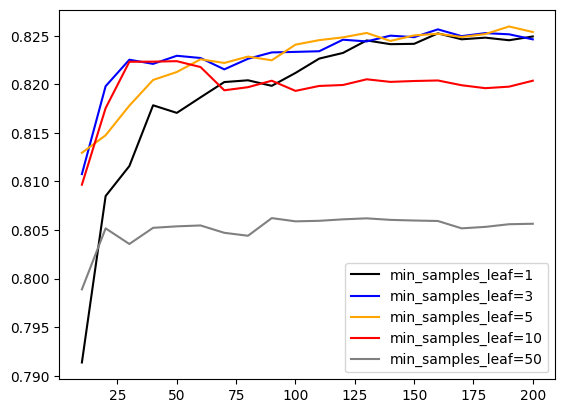

In [303]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
values = [1, 3, 5, 10, 50]

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [304]:
n_estimators=200
max_depth = 10
min_samples_leaf = 3

rf = RandomForestClassifier(n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=1)
rf.fit(X_train, y_train)


## Otros parametros importaentes = 
# - max_features 
# -bbootstrap

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [305]:
# Gradient boosting and XGBoost
#!pip install xgboost




In [306]:
import xgboost as xgb

features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)


In [341]:
watchlist = [(dtrain, 'train'), (dval, 'val')]


xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)


[0]	train-auc:0.86653	val-auc:0.77999
[5]	train-auc:0.92969	val-auc:0.80822
[10]	train-auc:0.95512	val-auc:0.81115
[15]	train-auc:0.96767	val-auc:0.81993
[20]	train-auc:0.97648	val-auc:0.81877
[25]	train-auc:0.98248	val-auc:0.81520
[30]	train-auc:0.98844	val-auc:0.81613
[35]	train-auc:0.99244	val-auc:0.81453
[40]	train-auc:0.99393	val-auc:0.81407
[45]	train-auc:0.99568	val-auc:0.81392
[50]	train-auc:0.99723	val-auc:0.81276
[55]	train-auc:0.99804	val-auc:0.81299
[60]	train-auc:0.99861	val-auc:0.81244
[65]	train-auc:0.99916	val-auc:0.81197
[70]	train-auc:0.99962	val-auc:0.81243
[75]	train-auc:0.99975	val-auc:0.81152
[80]	train-auc:0.99989	val-auc:0.81359
[85]	train-auc:0.99993	val-auc:0.81193
[90]	train-auc:0.99998	val-auc:0.81038
[95]	train-auc:0.99999	val-auc:0.80871
[100]	train-auc:0.99999	val-auc:0.80842
[105]	train-auc:1.00000	val-auc:0.80778
[110]	train-auc:1.00000	val-auc:0.80764
[115]	train-auc:1.00000	val-auc:0.80722
[120]	train-auc:1.00000	val-auc:0.80750
[125]	train-auc:1.0000

In [ ]:
# Defino esta funcion para poder tener el output de xgb

def get_xgb_scores(evals_result):
    train_aucs = list(evals_result['train'].values())[0]
    val_aucs = list(evals_result['val'].values())[0]

    # Definimos los nombres de las columnas
    columns = ['iter', 'train_auc', 'val_auc']

    # Creamos un DataFrame combinando la lista de iteraciones, train_aucs y val_aucs
    df_results = pd.DataFrame(
        list(zip(
            # Generamos la columna de iteración (desde 1 hasta el final)
            range(1, len(train_aucs) + 1),
            train_aucs,
            val_aucs
        )), 
        columns=columns
    )
    
    return df_results



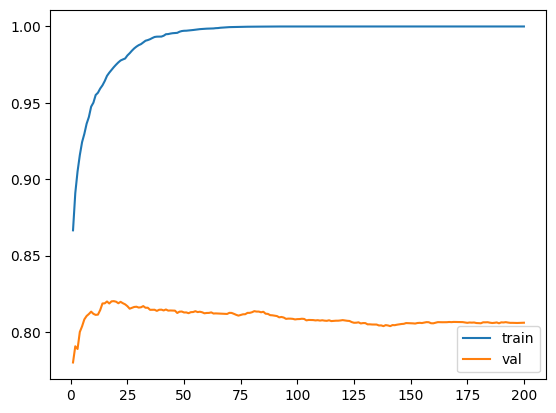

In [311]:
df_scores = get_xgb_scores(evals_result)

plt.plot(df_scores.iter, df_scores.train_auc, label='train')
plt.plot(df_scores.iter, df_scores.val_auc, label='val')
plt.legend()

In [329]:
scores = {}

In [334]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)


[0]	train-auc:0.77610	val-auc:0.73891
[5]	train-auc:0.83058	val-auc:0.77600
[10]	train-auc:0.85036	val-auc:0.79448
[15]	train-auc:0.85993	val-auc:0.80317
[20]	train-auc:0.86898	val-auc:0.80852
[25]	train-auc:0.87768	val-auc:0.81474
[30]	train-auc:0.88186	val-auc:0.81747
[35]	train-auc:0.88619	val-auc:0.81957
[40]	train-auc:0.88961	val-auc:0.82042
[45]	train-auc:0.89281	val-auc:0.82407
[50]	train-auc:0.89673	val-auc:0.82755
[55]	train-auc:0.89964	val-auc:0.82759
[60]	train-auc:0.90252	val-auc:0.82725
[65]	train-auc:0.90552	val-auc:0.82771
[70]	train-auc:0.90859	val-auc:0.82809
[75]	train-auc:0.91031	val-auc:0.82813
[80]	train-auc:0.91216	val-auc:0.82920
[85]	train-auc:0.91443	val-auc:0.83015
[90]	train-auc:0.91623	val-auc:0.83121
[95]	train-auc:0.91794	val-auc:0.83059
[100]	train-auc:0.91922	val-auc:0.83093
[105]	train-auc:0.92055	val-auc:0.83121
[110]	train-auc:0.92290	val-auc:0.83152
[115]	train-auc:0.92394	val-auc:0.83091
[120]	train-auc:0.92517	val-auc:0.83134
[125]	train-auc:0.9265

In [335]:
key = f'max_depth={xgb_params['max_depth']}'
scores[key] = get_xgb_scores(evals_result)
key
scores

{'max_depth=6':      iter  train_auc   val_auc
 0       1   0.866526  0.779991
 1       2   0.871342  0.773101
 2       3   0.889254  0.791498
 3       4   0.898860  0.795500
 4       5   0.901510  0.796623
 ..    ...        ...       ...
 195   196   0.999301  0.822713
 196   197   0.999317  0.822646
 197   198   0.999343  0.822579
 198   199   0.999352  0.822501
 199   200   0.999351  0.822186
 
 [200 rows x 3 columns],
 'max_depth=4':      iter  train_auc   val_auc
 0       1   0.816653  0.760008
 1       2   0.819131  0.763084
 2       3   0.832941  0.778481
 3       4   0.844040  0.783185
 4       5   0.846863  0.783594
 ..    ...        ...       ...
 195   196   0.973337  0.827223
 196   197   0.973495  0.827229
 197   198   0.973699  0.827350
 198   199   0.973861  0.827138
 199   200   0.974022  0.827266
 
 [200 rows x 3 columns],
 'max_depth=3':      iter  train_auc   val_auc
 0       1   0.776102  0.738908
 1       2   0.809908  0.774409
 2       3   0.819737  0.775747
 3   

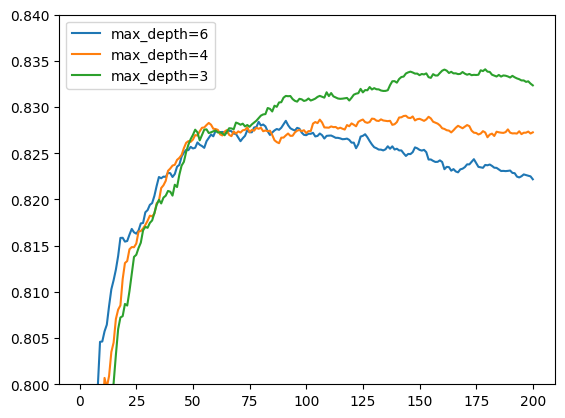

In [337]:
for max_depth, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=max_depth)

plt.ylim(0.8, 0.84)
plt.legend()

In [ ]:
# asi lo hacemos para cada uno de los 3 parametros en el orden ( eta,max_depth, min_child_weight),
#  y nos quedamos con el mejor corte y valor de cada uno. Aca es un ej con max_depth nomas

In [338]:
# Mejores valores
xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)